Duración promedio total de eventos de sequía: 2.96 meses
Duración máxima registrada: 14 meses
Duración promedio Periodo 1 (2000-2011): 2.80 meses
Duración promedio Periodo 2 (2012-2023): 3.12 meses


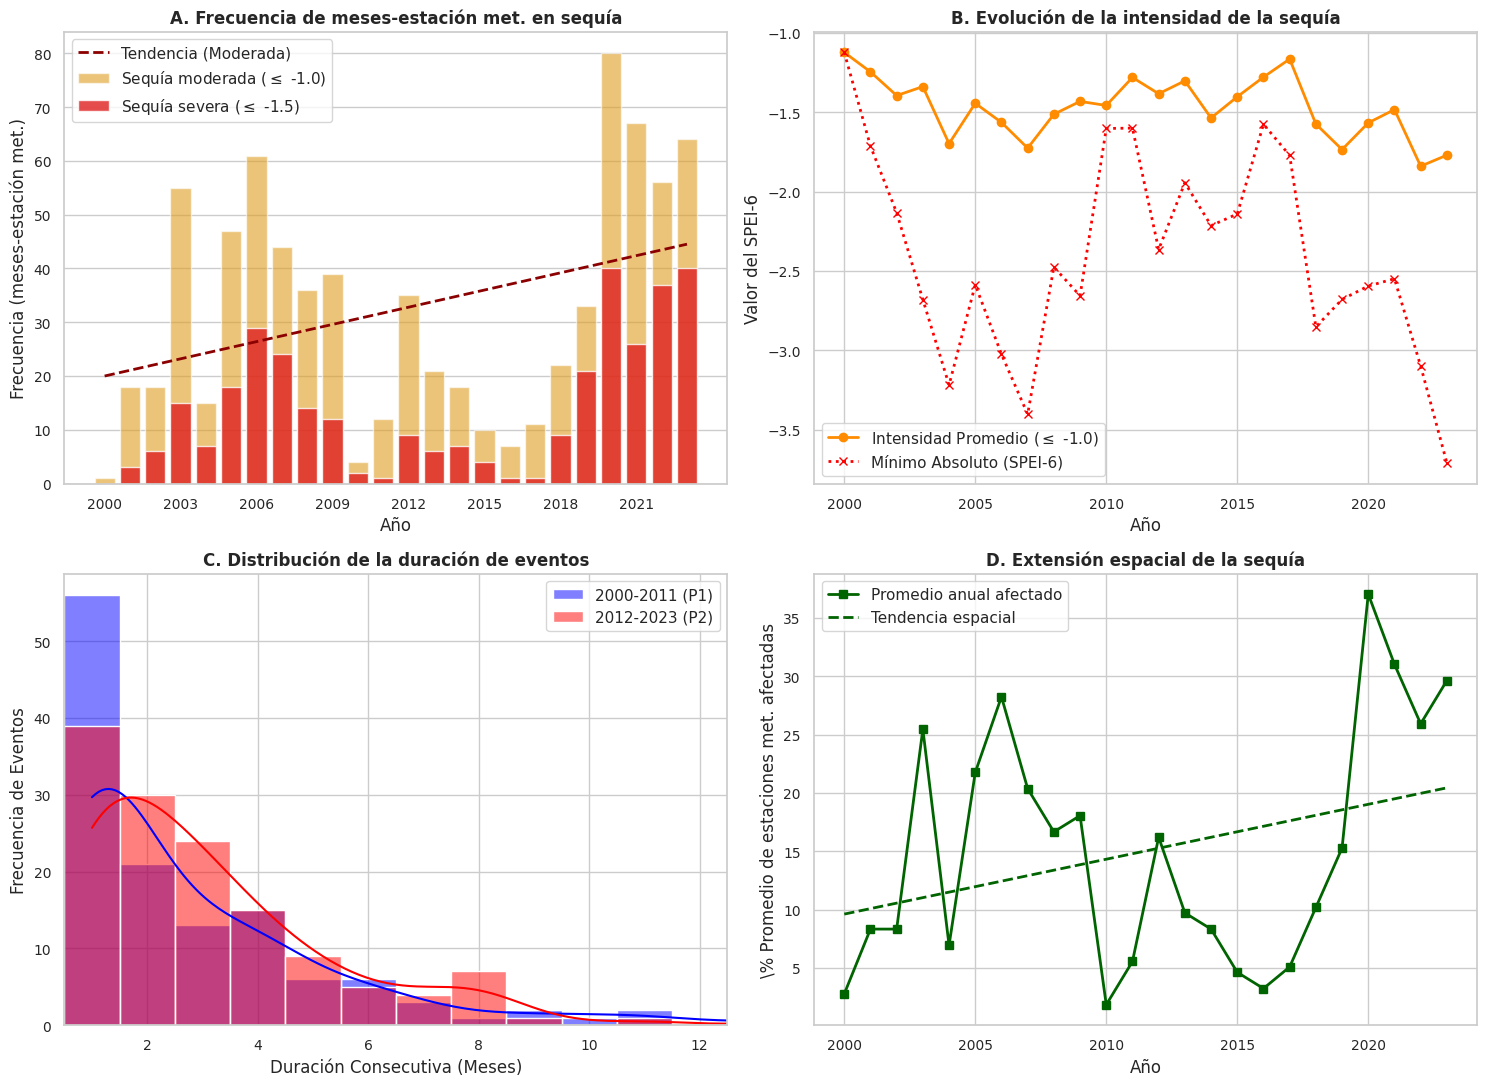

Frecuencia máxima de meses-estación met. en sequía: 80 (Año 2020)
Mínimo histórico absoluto de SPEI-6: -3.7103 registrado en MCAL el 2023-12


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Configuración estética de los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'xtick.labelsize': 10, 'ytick.labelsize': 10})

# 1. Carga de datos
df_datos = pd.read_csv('/home/hjvargaso/proyectos/tesis_sequia_2/data/processed/datos_mensuales_con_spei.csv')
df_datos['fecha'] = pd.to_datetime(df_datos['fecha'])
df_datos['año'] = df_datos['fecha'].dt.year
df_datos['mes'] = df_datos['fecha'].dt.month

# Pivotar matriz de SPEI-6
df_pivot = df_datos.pivot(index='estacion_id', columns='fecha', values='spei_6')
df_pivot = df_pivot.interpolate(method='linear', axis=1).bfill(axis=1) # Imputación de soporte


# CÁLCULOS ESTADÍSTICOS DE CARACTERIZACIÓN
# ==============================================================================

# A. FRECUENCIA: Conteo anual de meses-estación en sequía moderada (<= -1.0) y severa (<= -1.5)
df_datos['sequia_moderada'] = df_datos['spei_6'] <= -1.0
df_datos['sequia_severa'] = df_datos['spei_6'] <= -1.5

frecuencia_anual = df_datos.groupby('año')[['sequia_moderada', 'sequia_severa']].sum().reset_index()

# B. INTENSIDAD: Intensidad promedio de los meses en sequía (SPEI-6 <= -1.0) y mínimo absoluto anual
intensidad_anual = df_datos[df_datos['spei_6'] <= -1.0].groupby('año')['spei_6'].mean().reset_index()
intensidad_anual.columns = ['año', 'intensidad_promedio']
minimo_anual = df_datos.groupby('año')['spei_6'].min().reset_index()
minimo_anual.columns = ['año', 'spei_minimo']
df_intensidad = pd.merge(intensidad_anual, minimo_anual, on='año')

# C. DURACIÓN: Análisis de Rachas (Run-Length) de meses consecutivos con SPEI-6 <= -1.0
def calcular_duraciones_estacion(series, threshold=-1.0):
    is_drought = series <= threshold
    duraciones = []
    run = 0
    for val in is_drought:
        if val:
            run += 1
        else:
            if run > 0:
                duraciones.append(run)
                run = 0
    if run > 0:
        duraciones.append(run)
    return duraciones

duraciones_totales = []
for est in df_pivot.index:
    duraciones_totales.extend(calcular_duraciones_estacion(df_pivot.loc[est]))

duracion_media = np.mean(duraciones_totales)
duracion_maxima = np.max(duraciones_totales)

# Agrupando por periodos de tiempo para ver evolución de duración (2000-2011 vs 2012-2023)
dur_P1, dur_P2 = [], []
for est in df_pivot.index:
    dur_P1.extend(calcular_duraciones_estacion(df_pivot.loc[est, : '2011-12-31']))
    dur_P2.extend(calcular_duraciones_estacion(df_pivot.loc[est, '2012-01-01' :]))

print(f"Duración promedio total de eventos de sequía: {duracion_media:.2f} meses")
print(f"Duración máxima registrada: {duracion_maxima} meses")
print(f"Duración promedio Periodo 1 (2000-2011): {np.mean(dur_P1):.2f} meses")
print(f"Duración promedio Periodo 2 (2012-2023): {np.mean(dur_P2):.2f} meses")

# D. EXTENSIÓN ESPACIAL: % de estaciones afectadas simultáneamente (SPEI-6 <= -1.0) por mes
extension_mensual = df_pivot.apply(lambda x: (x <= -1.0).sum() / len(x) * 100, axis=0).reset_index()
extension_mensual.columns = ['fecha', 'pct_afectado']
extension_mensual['año'] = extension_mensual['fecha'].dt.year
extension_anual = extension_mensual.groupby('año')['pct_afectado'].mean().reset_index()

# ==============================================================================
# GENERACIÓN DE GRÁFICAS DE ALTA CALIDAD (2x2)
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Gráfica 1: Frecuencia de Eventos (Moderados vs. Severos) con Línea de Tendencia
sns.barplot(data=frecuencia_anual, x='año', y='sequia_moderada', color='orange', alpha=0.6, label=r'Sequía moderada ($\leq$ -1.0)', ax=axes[0,0])
sns.barplot(data=frecuencia_anual, x='año', y='sequia_severa', color='red', alpha=0.8, label=r'Sequía severa ($\leq$ -1.5)', ax=axes[0,0])
# Tendencia lineal para Sequía Moderada
x = frecuencia_anual['año'] - frecuencia_anual['año'].min()
y = frecuencia_anual['sequia_moderada']
res = sm.OLS(y, sm.add_constant(x)).fit()
axes[0,0].plot(axes[0,0].get_xticks(), res.predict(sm.add_constant(x)), color='darkred', linestyle='--', linewidth=2, label='Tendencia (Moderada)')
axes[0,0].set_title("A. Frecuencia de meses-estación met. en sequía", fontweight='bold')
axes[0,0].set_xlabel("Año")
axes[0,0].set_ylabel("Frecuencia (meses-estación met.)")
axes[0,0].set_xticks(axes[0,0].get_xticks()[::3]) # Mostrar años cada 3 años
axes[0,0].legend()

# Gráfica 2: Evolución de la Intensidad Mínima y Promedio
axes[0,1].plot(df_intensidad['año'], df_intensidad['intensidad_promedio'], marker='o', color='darkorange', linewidth=2, label=r'Intensidad Promedio ($\leq$ -1.0)')
axes[0,1].plot(df_intensidad['año'], df_intensidad['spei_minimo'], marker='x', color='red', linestyle=':', linewidth=2, label='Mínimo Absoluto (SPEI-6)')
axes[0,1].set_title("B. Evolución de la intensidad de la sequía", fontweight='bold')
axes[0,1].set_xlabel("Año")
axes[0,1].set_ylabel("Valor del SPEI-6")
axes[0,1].legend()

# Gráfica 3: Histograma Comparativo de Duración (P1 vs P2)
sns.histplot(dur_P1, color='blue', alpha=0.5, label='2000-2011 (P1)', kde=True, discrete=True, ax=axes[1,0])
sns.histplot(dur_P2, color='red', alpha=0.5, label='2012-2023 (P2)', kde=True, discrete=True, ax=axes[1,0])
axes[1,0].set_title("C. Distribución de la duración de eventos", fontweight='bold')
axes[1,0].set_xlabel("Duración Consecutiva (Meses)")
axes[1,0].set_ylabel("Frecuencia de Eventos")
axes[1,0].set_xlim(0.5, 12.5)
axes[1,0].legend()

# Gráfica 4: Extensión Espacial de la Sequía (% de Estaciones Afectadas)
axes[1,1].plot(extension_anual['año'], extension_anual['pct_afectado'], marker='s', color='darkgreen', linewidth=2, label='Promedio anual afectado')
# Tendencia espacial
res_sp = sm.OLS(extension_anual['pct_afectado'], sm.add_constant(x)).fit()
axes[1,1].plot(extension_anual['año'], res_sp.predict(sm.add_constant(x)), color='darkgreen', linestyle='--', linewidth=2, label='Tendencia espacial')
axes[1,1].set_title("D. Extensión espacial de la sequía", fontweight='bold')
axes[1,1].set_xlabel("Año")
axes[1,1].set_ylabel(r"\% Promedio de estaciones met. afectadas")
axes[1,1].legend()

plt.tight_layout()
plt.savefig('caracterizacion_descriptiva_sequia.png', dpi=300)
plt.show()

# Métricas descriptivas clave para la redacción
print(f"Frecuencia máxima de meses-estación met. en sequía: {frecuencia_anual['sequia_moderada'].max()} (Año {frecuencia_anual.loc[frecuencia_anual['sequia_moderada'].idxmax(), 'año']})")
print(f"Mínimo histórico absoluto de SPEI-6: {df_datos['spei_6'].min()} registrado en {df_datos.loc[df_datos['spei_6'].idxmin(), 'estacion_id']} el {df_datos.loc[df_datos['spei_6'].idxmin(), 'fecha'].strftime('%Y-%m')}")